In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include="all"))

Dataset Shape: (891, 15)

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_report = missing_report[missing_report["Missing Values"] > 0]

display(missing_report)

,Missing Values,Missing Percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


In [5]:
# Handle missing values

# Age: fill with median
df["age"] = df["age"].fillna(df["age"].median())

# Embarked: fill with mode
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Drop deck because it has too many missing values
df = df.drop(columns=["deck"])

# Drop embark_town because it duplicates embarkation information
df = df.drop(columns=["embark_town"])

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64


In [6]:
for column in ["age", "fare"]:
    print(f"\n--- {column.upper()} ANALYSIS ---")
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Mode:", df[column].mode()[0])
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())


--- AGE ANALYSIS ---
Mean: 29.36158249158249
Median: 28.0
Mode: 28.0
Minimum: 0.42
Maximum: 80.0

--- FARE ANALYSIS ---
Mean: 32.204207968574636
Median: 14.4542
Mode: 8.05
Minimum: 0.0
Maximum: 512.3292


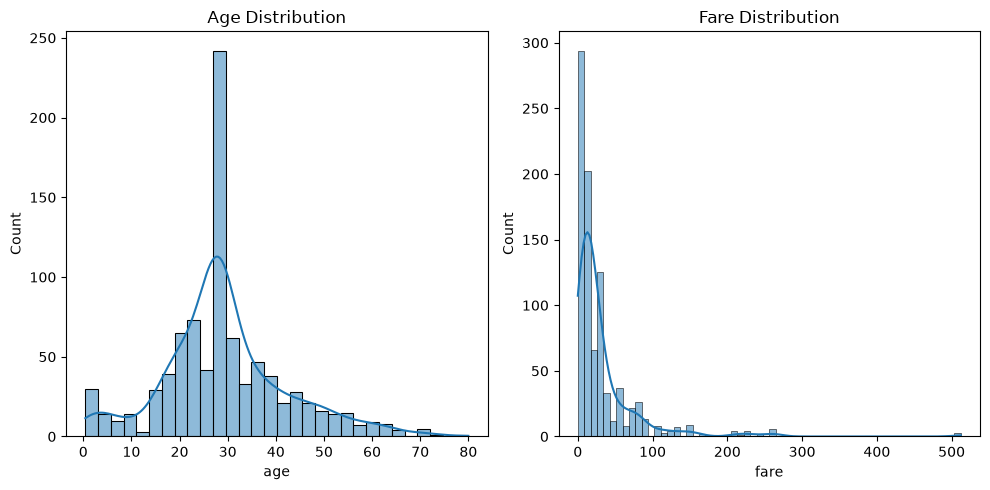

In [7]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df["fare"], kde=True)
plt.title("Fare Distribution")

plt.tight_layout()
plt.show()

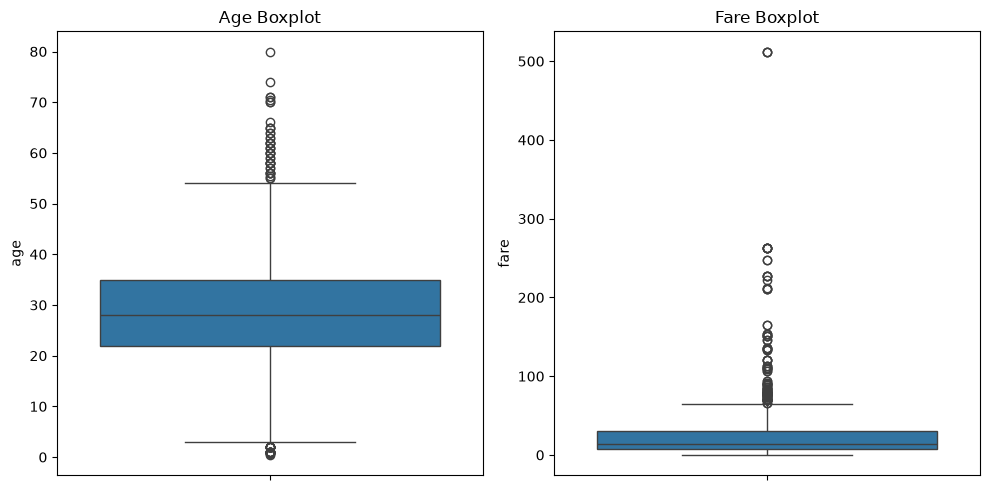

In [8]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["age"])
plt.title("Age Boxplot")

plt.subplot(1, 2, 2)
sns.boxplot(y=df["fare"])
plt.title("Fare Boxplot")

plt.tight_layout()
plt.show()

In [9]:
for column in ["age", "fare"]:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) | 
        (df[column] > upper_bound)
    ]
    
    print(f"\n--- {column.upper()} OUTLIER ANALYSIS ---")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))


--- AGE OUTLIER ANALYSIS ---
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower Bound: 2.5
Upper Bound: 54.5
Number of Outliers: 66

--- FARE OUTLIER ANALYSIS ---
Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344
Number of Outliers: 116


In [10]:
# Select numerical columns
numerical_df = df.select_dtypes(include=["int64", "float64"])

# Correlation matrix
correlation = numerical_df.corr()

print(correlation)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.338481 -0.064910 -0.035322  0.081629  0.257307
pclass   -0.338481  1.000000 -0.339898  0.083081  0.018443 -0.549500
age      -0.064910 -0.339898  1.000000 -0.233296 -0.172482  0.096688
sibsp    -0.035322  0.083081 -0.233296  1.000000  0.414838  0.159651
parch     0.081629  0.018443 -0.172482  0.414838  1.000000  0.216225
fare      0.257307 -0.549500  0.096688  0.159651  0.216225  1.000000


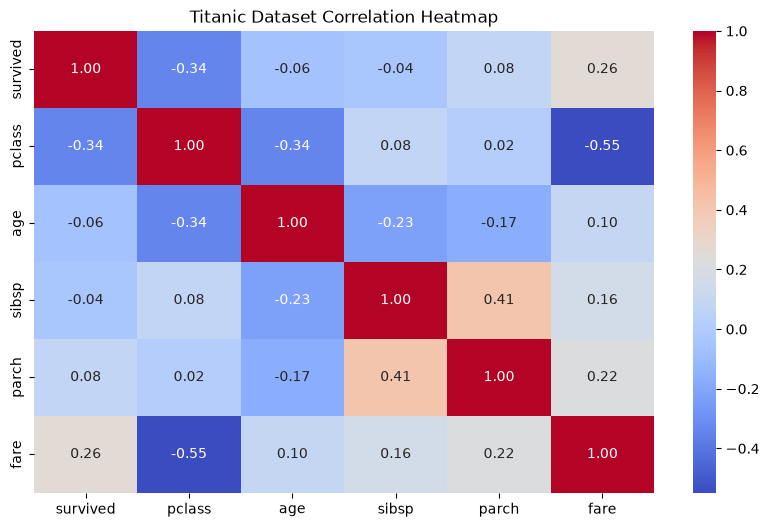

In [11]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Titanic Dataset Correlation Heatmap")
plt.show()

In [12]:
# Survival Rate Analysis

print("SURVIVAL RATE BY SEX")
print(df.groupby('sex')['survived'].mean() * 100)

print("\nSURVIVAL RATE BY CLASS")
print(df.groupby('class', observed=False)['survived'].mean() * 100)

print("\nSURVIVAL RATE BY PCLASS")
print(df.groupby('pclass')['survived'].mean() * 100)

SURVIVAL RATE BY SEX
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

SURVIVAL RATE BY CLASS
class
First     62.962963
Second    47.282609
Third     24.236253
Name: survived, dtype: float64

SURVIVAL RATE BY PCLASS
pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


In [13]:
# Survival rate using Boolean Masking

# (a) Survival rate by sex
female_survival_rate = (
    df[(df["sex"] == "female") & (df["survived"] == 1)].shape[0]
    / df[df["sex"] == "female"].shape[0]
) * 100

male_survival_rate = (
    df[(df["sex"] == "male") & (df["survived"] == 1)].shape[0]
    / df[df["sex"] == "male"].shape[0]
) * 100

print("Female Survival Rate:", female_survival_rate)
print("Male Survival Rate:", male_survival_rate)


# (b) Survival rate by pclass
for pclass in [1, 2, 3]:
    rate = (
        df[(df["pclass"] == pclass) & (df["survived"] == 1)].shape[0]
        / df[df["pclass"] == pclass].shape[0]
    ) * 100
    
    print(f"Pclass {pclass} Survival Rate: {rate:.2f}%")

Female Survival Rate: 74.20382165605095
Male Survival Rate: 18.890814558058924
Pclass 1 Survival Rate: 62.96%
Pclass 2 Survival Rate: 47.28%
Pclass 3 Survival Rate: 24.24%


In [14]:
# (c) Survival rate by sex AND pclass together
for sex in ["female", "male"]:
    for pclass in [1, 2, 3]:
        
        group = df[
            (df["sex"] == sex) &
            (df["pclass"] == pclass)
        ]
        
        survived = group[
            group["survived"] == 1
        ]
        
        survival_rate = (len(survived) / len(group)) * 100
        
        print(
            f"{sex.capitalize()} | Pclass {pclass} | "
            f"Survival Rate: {survival_rate:.2f}%"
        )

Female | Pclass 1 | Survival Rate: 96.81%
Female | Pclass 2 | Survival Rate: 92.11%
Female | Pclass 3 | Survival Rate: 50.00%
Male | Pclass 1 | Survival Rate: 36.89%
Male | Pclass 2 | Survival Rate: 15.74%
Male | Pclass 3 | Survival Rate: 13.54%


In [15]:
# Exactly the six required numeric columns
columns = ["survived", "pclass", "age", "sibsp", "parch", "fare"]

corr = df[columns].corr()

# Get unique off-diagonal correlation pairs
pairs = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
).stack()

# Rank by absolute correlation
top_2 = pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(2)

print("Top 2 Strongest Correlations:")
print(top_2)

Top 2 Strongest Correlations:
pclass  fare    -0.549500
sibsp   parch    0.414838
dtype: float64


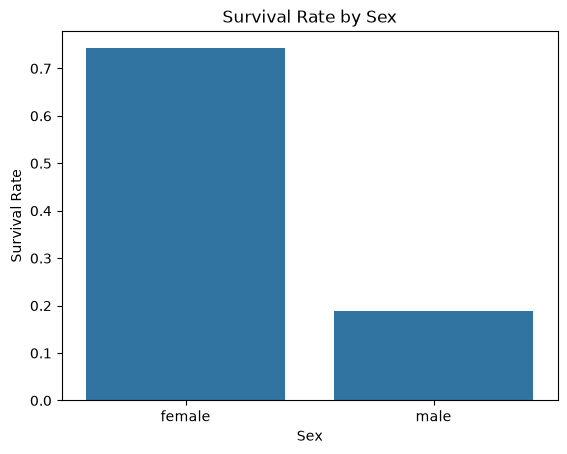

In [16]:
survival_by_sex = df.groupby("sex")["survived"].mean().reset_index()

sns.barplot(data=survival_by_sex, x="sex", y="survived")

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.show()

Female passengers had a significantly higher survival rate than male passengers.
The survival rate for females was approximately 74%, while for males it was approximately 19%.
This indicates that gender was an important factor influencing survival on the Titanic.

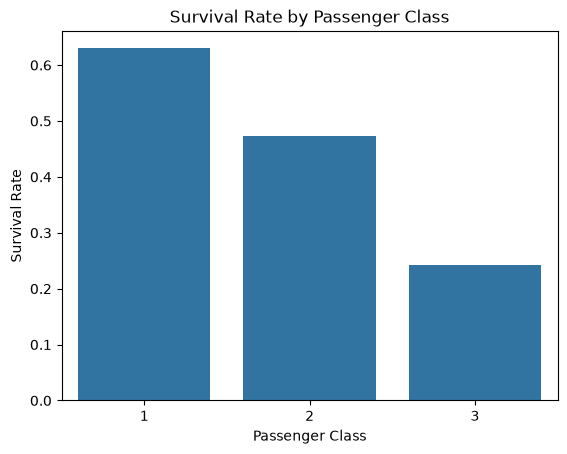

In [17]:
survival_by_class = df.groupby("pclass")["survived"].mean().reset_index()

sns.barplot(data=survival_by_class, x="pclass", y="survived")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

First-class passengers had the highest survival rate, followed by second-class passengers. Third-class passengers had the lowest survival rate. This suggests that passenger class was an important factor influencing the likelihood of survival on the Titanic.

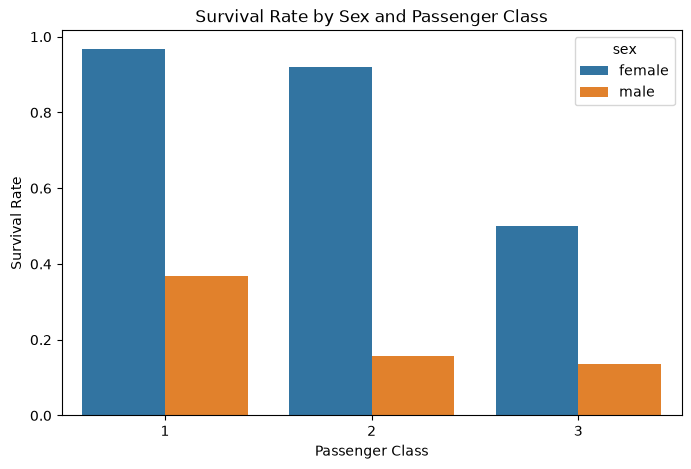

In [18]:
# Chart 3: Survival Rate by Sex and Passenger Class

survival_sex_class = df.groupby(
    ['sex', 'pclass']
)['survived'].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=survival_sex_class,
    x='pclass',
    y='survived',
    hue='sex'
)

plt.title('Survival Rate by Sex and Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')

plt.show()

Female passengers had higher survival rates than male passengers across all passenger classes. First-class females had the highest survival rate, while third-class males had the lowest survival rate. This shows that both sex and passenger class together strongly influenced the likelihood of survival.

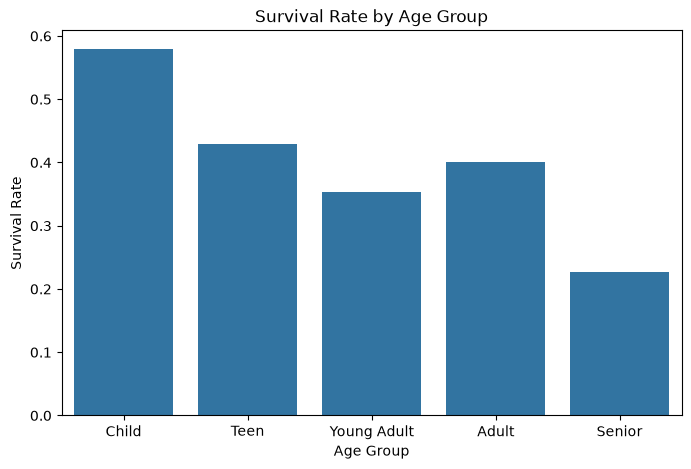

In [19]:
# Chart 4: Survival Rate by Age Group

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

survival_by_age = df.groupby(
    'age_group',
    observed=False
)['survived'].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=survival_by_age,
    x='age_group',
    y='survived'
)

plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')

plt.show()

Children had the highest survival rate among the age groups, while senior passengers had the lowest survival rate. The survival rates generally varied across different age groups, indicating that age also influenced the likelihood of survival. This adds another factor to the overall data story, along with sex and passenger class.

In [21]:
# Z-score Standardization for EDA

# Before standardization
print("BEFORE STANDARDIZATION")
print(df[['age', 'fare']].agg(['mean', 'std']))

# Create standardized columns using z-score
df['age_zscore'] = (df['age'] - df['age'].mean()) / df['age'].std()
df['fare_zscore'] = (df['fare'] - df['fare'].mean()) / df['fare'].std()

# After standardization
print("\nAFTER STANDARDIZATION")
print(df[['age_zscore', 'fare_zscore']].agg(['mean', 'std']))

BEFORE STANDARDIZATION
            age       fare
mean  29.361582  32.204208
std   13.019697  49.693429

AFTER STANDARDIZATION
        age_zscore   fare_zscore
mean  2.232906e-16 -1.196200e-17
std   1.000000e+00  1.000000e+00


In [22]:
# Save the cleaned Titanic dataset as the required offline fallback
df.to_csv("titanic.csv", index=False)

print("Cleaned Titanic dataset saved as titanic.csv")
print("Shape:", df.shape)

Cleaned Titanic dataset saved as titanic.csv
Shape: (891, 16)


In [23]:
from pathlib import Path

output_path = Path("titanic.csv")

df.to_csv(output_path, index=False)

print("Saved:", output_path.resolve())
print("Shape:", df.shape)

Saved: C:\Users\ASUS\Documents\zepto-data-ai-capstone-project\analytics\titanic.csv
Shape: (891, 16)
